# HW 2. RAG, векторная база и память агента

На прошлой неделе агент ходил за фактами в живую Википедию и отвечал на 58 процентов свежих вопросов. Сегодня кладём знания рядом: режем корпус на куски, считаем эмбеддинги, ищем сначала на numpy, потом в Milvus, собираем RAG-ответ с источниками, разбираем провалы и даём агенту память. В конце превращаем поиск в инструмент агента. Дополнение для желающих: тот же конвейер на PDF.

Тезис курса прежний: **хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.** Сегодняшний вопрос к нему: сколько стоит верный ответ, когда знания лежат в индексе, и сколько в этой цене занимает контекст.

Восемь спринтов, десять дырок. Дырка это функция, у которой вместо тела стоит `...`, ни одна не длиннее десяти строк. Пояснения к дыркам, хронометраж и домашка в `README.md`.

## Что нужно

**Ключ** OpenRouter: локально файл `.env` рядом с ноутбуком, в Kaggle секрет `OPENROUTER_API_KEY` (Add-ons, Secrets, галочка подключения, перезапуск сессии). **Данные**: папка `data` рядом с ноутбуком, в Kaggle датасет `seminar02-data` и включённый Internet.

**Milvus** в Docker: в папке семинара лежит `docker-compose.yml`, команда `docker compose up -d` поднимает базу на `localhost:19530`. Первый запуск скачивает образ, около гигабайта, поэтому сделайте это до семинара. Если Docker поставить нельзя (Kaggle, Colab), в README есть раздел «Нет Docker».

В данных лежит готовый файл эмбеддингов корпуса `embeddings_512.npz`. С ним второй спринт занимает секунды. Без него те же векторы посчитаются через API за цент и минут двадцать: так было у нас при подготовке, и на общей сети аудитории будет не быстрее.

In [1]:
%pip install -q requests pydantic python-dotenv pandas matplotlib numpy pymilvus pypdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
PROXY = 'socks5h://127.0.0.1:1081'

In [2]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}", "X-Title": "agents-course-seminar02"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("data"), Path("/kaggle/input/seminar02-data"), Path("/kaggle/input/seminar02-data/data")]
             if (p / "corpus_2026.jsonl").exists()), Path("data"))
Path("img").mkdir(exist_ok=True)


@dataclass
class Ledger:
    calls: list = field(default_factory=list)
    local: threading.local = field(default_factory=threading.local)

    def add(self, tag, model, usage, seconds=0.0):
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": usage.get("prompt_tokens", 0),
                           "completion": usage.get("completion_tokens", 0), "cost": cost, "seconds": round(seconds, 2)})
        self.local.spent = self.mine + cost
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    @property
    def mine(self):
        return getattr(self.local, "spent", 0.0)

    def table(self):
        frame = pd.DataFrame(self.calls, columns=["tag", "model", "prompt", "completion", "cost", "seconds"])
        return frame.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                                      completion=("completion", "sum"), cost=("cost", "sum")).round(5)


ledger = Ledger()

def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    proxies = None
    if PROXY:
        proxies = {"http": PROXY, "https": PROXY}
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, proxies = proxies, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)


def chat(messages, model, tools=None, tag="chat"):
    body = {"model": model, "messages": messages, "temperature": 0, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    started = time.perf_counter()
    data = post_with_retry(CHAT_URL, body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

## Шаг 1. Корпус и вопросы

Корпус это 28 обзорных страниц Википедии про 2026 год, 830 тысяч символов. Вопросы те же, что в первой домашке: 124 штуки, на которых Sonnet без инструментов не отвечает. У каждого вопроса есть поле `evidence`, исходная строка с ответом, поэтому мы точно знаем, какой кусок верный, и сможем считать качество поиска без ручной разметки.

Страница устроена как список датированных событий: одна строка, одно событие. Отсюда два способа резать. Наивный: по 400 символов, не глядя на границы. По структуре: одна строка это один кусок, а заголовок раздела (месяц) едет с куском как метаданные.

Дырка: нарезка по строкам. Чекпоинт: число кусков в обеих нарезках и пример факта, который наивная нарезка разорвала пополам.

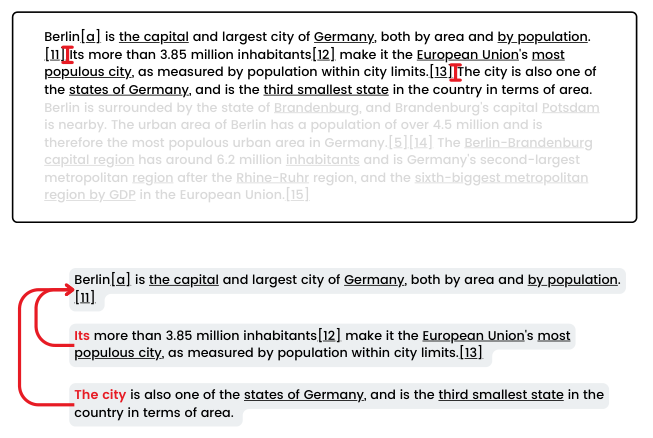

*Günther et al., 2024. Кусок без контекста: во втором и третьем предложении слова «Берлин» уже нет. Поэтому к тексту куска мы приписываем название страницы*

In [3]:
corpus, tasks = load_jsonl("corpus_2026.jsonl"), load_jsonl("fresh_2026.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), tasks[0]

(2,
 31660,
 20,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': "What particle did physicists at CERN's LHCb experiment report discovering on 17 March 2026?",
  'answer': 'doubly charmed baryon Ξcc⁺',
  'evidence': "17 March – Physicists at CERN's LHCb experiment report the discovery of the doubly charmed baryon Ξcc⁺.",
  'page': '2026 in science',
  'url': 'https://en.wikipedia.org/wiki/2026_in_science',
  'agent_ok': False})

In [4]:
def chunk_lines(page):
    chunks, section = [], ""
    for line in page["text"].splitlines():
        line = " ".join(line.split())
        if line.startswith("="):
            section = line.strip('= ')
        elif len(line) > 40:
            chunks.append({"page": page["page"], "section": section, "url" : page["url"], "text": line})
    return chunks

In [5]:
print("====== 2 + 2 == 4".strip('= '))

2 + 2 == 4


In [6]:
# Сематическая ручная разбивка
sem_chunks = load_jsonl('semantic_chunks.jsonl') 
line_chunks = [c for p in corpus for c in chunk_lines(p)]
len(line_chunks), len(sem_chunks), line_chunks[10]

(109,
 106,
 {'page': '2026 in science',
  'section': 'January',
  'url': 'https://en.wikipedia.org/wiki/2026_in_science',
  'text': 'Researchers from the University of Copenhagen publish a Nature paper explaining little red dots as young and relatively small supermassive black holes enshrouded in a dense cocoon of ionized gas.'})

In [7]:
sem_chunks[0]

{'chunk_id': 0,
 'page': '2026 in science',
 'url': 'https://en.wikipedia.org/wiki/2026_in_science',
 'date': '1 January',
 'section': 'January',
 'text': "Researchers operating China's Experimental Advanced Superconducting Tokamak (EAST) report the first experimental verification of a theorised density-free plasma operating regime, achieving stable electron densities approximately 1.3–1.65 times the Greenwald limit."}

## Шаг 2. Индекс в Milvus и качество поиска

Эмбеддинг текста не меняется, пока не меняются текст и модель, поэтому считать его дважды незачем. Кэш устроен просто: ключ это хэш текста, значение это вектор. Сначала в кэш загружается готовый файл из данных, потом всё, чего там нет, досчитывается через API пачками по 64 текста.

Вектор берём укороченный, 512 измерений вместо 1536: это «матрёшка» из пятой лекции, параметр `dimensions` в запросе. Ответ API втрое легче, память втрое меньше, качество почти то же. Пачка в 256 текстов на полной размерности это восемь мегабайт JSON, и на медленной сети такой запрос просто не доходит.

Дырка: `embed_cached`. Чекпоинт: матрицы векторов для обеих нарезок и вопросов и строка в леджере с ценой.

### Шаг 2.1. Эмбеддинги и индексация

In [9]:
EMB = {}

def load_cache():
    for path in [DATA / "embeddings_512.npz", Path("emb_cache.npz")]:
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def save_cache():
    np.savez_compressed("emb_cache.npz", keys=np.array(list(EMB)), vectors=np.stack(list(EMB.values())).astype(np.float16))

def embed_batch(texts):
    started = time.perf_counter()
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    ledger.add("embed", EMBED_MODEL, data.get("usage") or {}, time.perf_counter() - started)
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

load_cache()

8017

In [10]:
def embed_cached(texts):
    missing = list(dict.fromkeys(t for t in texts if key_of(t) not in EMB)) #set нельзя т.к. нет порядка
    for i in range(0, len(missing), 64):
        batch = missing[i:i+64]
        for text, vector in zip(batch, embed_batch(batch)):
            EMB[key_of(text)] = np.asarray(vector, dtype=np.float32)

    vectors = np.stack([EMB[key_of(t)] for t in texts])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
        


In [11]:
line_chunks[0]

{'page': '2026 in science',
 'section': '',
 'url': 'https://en.wikipedia.org/wiki/2026_in_science',
 'text': 'The following scientific events occurred, or are scheduled to occur in 2026.'}

In [12]:
def emb_text(chunk):
    return f"{chunk['page']}: {chunk['text']}"

line_vecs = embed_cached([emb_text(c) for c in line_chunks])
sem_vecs = embed_cached([c["text"] for c in sem_chunks])
q_vecs = embed_cached([t["question"] for t in tasks])
save_cache()

In [13]:
line_vecs.shape, sem_vecs.shape, q_vecs.shape

((109, 512), (106, 512), (20, 512))

In [20]:
# Проверяем Милвус
MILVUS_URI = os.getenv("MILVUS_URI", "http://localhost:19530")
client = MilvusClient(uri=MILVUS_URI, token=os.getenv("MILVUS_TOKEN", ""))
if os.getenv("MILVUS_DB"):
    if os.environ["MILVUS_DB"] not in client.list_databases():
        client.create_database(os.environ["MILVUS_DB"])
    client.use_database(os.environ["MILVUS_DB"])
client.get_server_version(), client.list_collections()

('2.6.24', [])

In [21]:
# Индексирование
def index_to_milvus(name, chunks, vectors):
    if client.has_collection(name):
        client.drop_collection
    client.create_collection(name, dimension=vectors.shape[1], metric_type="COSINE")
    rows = [{"id": i, "vector": v.tolist(), **c} for i, (c, v) in enumerate(zip(chunks, vectors))]
    for i in range(0, len(rows), 1000):
        client.insert(name, rows[i:i+1000])

    #client.flush(name)
    return client.get_collection_stats(name)

# Поиск
def search_milvus(name, query, k=5, flt=""):
    vector = embed_cached([query])[0].tolist()
    hits = client.search(name, data=[vector], limit=k, filter=flt, output_fields=["page", "section", "url", "text"])[0]

    return [{**h['entity'], "id": h["id"], "score": round(h["distance"], 4)} for h in hits ]

In [22]:
index_to_milvus("line", line_chunks, line_vecs), client.describe_index("line", "vector")

({'row_count': 0},
 {'index_type': 'AUTOINDEX',
  'metric_type': 'COSINE',
  'field_name': 'vector',
  'index_name': 'vector',
  'total_rows': 0,
  'indexed_rows': 0,
  'pending_index_rows': 0,
  'state': 'Finished'})

In [24]:
index_to_milvus("sem", sem_chunks, sem_vecs), client.describe_index("sem", "vector")

({'row_count': 0},
 {'index_type': 'AUTOINDEX',
  'metric_type': 'COSINE',
  'field_name': 'vector',
  'index_name': 'vector',
  'total_rows': 0,
  'indexed_rows': 0,
  'pending_index_rows': 0,
  'state': 'Finished'})

### Шаг 2.2. Поиск и замер recall

In [25]:
def search_milvus(name, query, k=5, flt=""):
    vector = embed_cached([query])[0].tolist()
    hits = client.search(name, data=[vector], limit=k, filter=flt, output_fields=["page", "section", "url", "text"])[0]

    return [{**h['entity'], "id": h["id"], "score": round(h["distance"], 4)} for h in hits ]

In [27]:
pd.DataFrame(search_milvus("line", tasks[0]["question"], 3))[["score", "page", "section", "text"]]

,score,page,section,text
0,0.7337,2026 in science,March,17 March – Physicists at CERN's LHCb experimen...
1,0.5203,2026 in science,January,Researchers led by the University of the Chine...
2,0.4630,2026 in science,March,Antimatter particles are transported by road f...


In [36]:
NUMBERS = {word: str(n) for n, word in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    words = re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split()
    return " ".join(NUMBERS.get(w, w) for w in words)

def is_gold(chunk, task):
    if chunk["page"] != task["page"]:
        return False
    text, words = norm(chunk["text"]), norm(task["evidence"]).split()
    return norm(task["answer"]) in text and sum(w in text for w in words) >= 0.5 * len(words)

def recall_curve(index_name, tasks, ks=(1, 3, 5, 10)):
    ranked = [search_milvus(index_name, task["question"], max(ks)) for task in tasks]
    return {k: float(np.mean([any(is_gold(i, t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

,по строкам,семантически
1,1.0,0.95
3,1.0,0.95
5,1.0,0.95
10,1.0,0.95


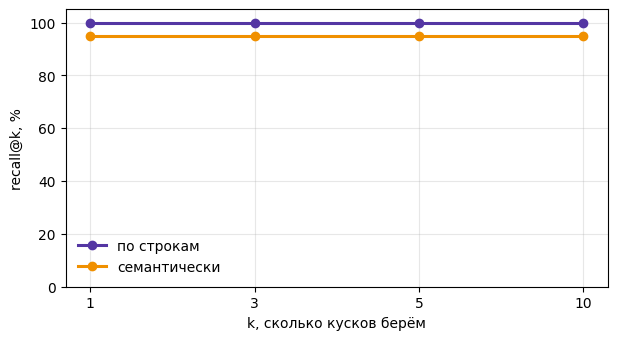

In [38]:
curves = {"по строкам": recall_curve("line", tasks), "семантически": recall_curve("sem", tasks)}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

In [45]:
texts = ["Привет, мама!", "мама мама мыла раму"]
def tokens(text):
    return re.findall(r"\w+", text.lower())


In [52]:
# добавляем поиск по словам
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

line_chunks_texts = [chunk['text'] for chunk in line_chunks]
docs, idf = build_keyword_index(line_chunks_texts)
query = "What particle did physicists at CERN's LHCb experiment report discovering on 17 March 2026?"
keyword_search(query, docs, idf, k = 10)

[30, 37, 106, 107, 48, 69, 26, 97, 23, 86]

In [66]:
# Добавляем гибридный поиск
def rrf(rankings, k=10, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] = scores.get(idx, 0.0) + 1 / (K + rank + 1)

    return sorted(scores, key=scores.get, reverse=True)[:k]

In [69]:
def recall_curve_tfidf(chunks, tasks, idf, ks=(1, 3, 5, 10)):
    ranked = [[i for i in keyword_search(task["question"], docs, idf, max(ks))] for task in tasks]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

def recall_curve_rrf(chunks, tasks, idf, ks=(1, 3, 5, 10)):
    index_name = "line"
    ranked_tfidf = [[i for i in keyword_search(task["question"], docs, idf, max(ks))] for task in tasks]
    ranked_cos = [[res["id"] for res in search_milvus(index_name, task["question"], max(ks))] for task in tasks]
    ranked = [rrf([rt, rc], k = max(ks)) for rt, rc in zip(ranked_tfidf, ranked_cos)]
    return {k: float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(ranked, tasks)])) for k in ks}

,по строкам,семантически,TF-IDF,RRF
1,1.0,0.95,1.0,1.0
3,1.0,0.95,1.0,1.0
5,1.0,0.95,1.0,1.0
10,1.0,0.95,1.0,1.0


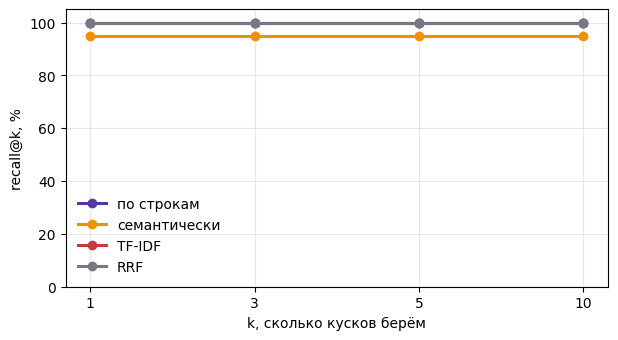

In [71]:
curves = {
    "по строкам": recall_curve("line", tasks), 
    "семантически": recall_curve("sem", tasks), 
    "TF-IDF": recall_curve_tfidf(line_chunks, tasks, idf),
    "RRF": recall_curve_rrf(line_chunks, tasks, idf),
}
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, curve), color in zip(curves.items(), [COLORS["violet"], COLORS["amber"], COLORS["red"], COLORS["grey"]]):
    ax.plot([str(k) for k in curve], [v * 100 for v in curve.values()], marker="o", lw=2.2, color=color, label=name)
ax.set_xlabel("k, сколько кусков берём"); ax.set_ylabel("recall@k, %"); ax.set_ylim(0, 105); ax.legend(frameon=False); ax.grid(alpha=0.3)
fig.savefig("img/recall.png", dpi=150, bbox_inches="tight")
pd.DataFrame(curves).round(2)

## ШАГ 3. RAG‐ответ, инструмент агента и замер

### ШАГ 3.1. RAG

In [72]:
RAG_SYSTEM = ("Answer the question using only the numbered sources. Cite the source number like [2]. "
              "If the sources do not contain the answer, reply exactly NOT_FOUND. The last line must be FINAL: <short answer>.")
PLAIN_SYSTEM = "Answer the question. If you do not know, reply NOT_FOUND. The last line must be FINAL: <short answer>."

In [98]:
def summary(config, model, n, correct, cost, steps, seconds=0.0):
    return {"config": config, "model": model.split("/")[-1], "n": n, "accuracy": round(correct / n, 2),
            "cost_per_task": round(cost / n, 5), "cost_per_correct": round(cost / correct, 5) if correct else float("inf"),
            "avg_steps": round(steps, 2), "avg_seconds": round(seconds, 1)}

In [78]:
def rag_answer(question, ):
    model = MODELS["cheap"]
    k = 3
    name = "line"
    hits = search_milvus(name, question, k)
    sources = "\n".join(f"[{i + 1}] ({h['page']}) {h['text']}" for i, h in enumerate(hits))
    before = ledger.mine
    msg = chat([{"role": "system", "content": RAG_SYSTEM},
                {"role": "user", "content": f"Sources\n{sources}\n\nQuestion:{question}"}], model, tag="rag")
    return {"answer": msg.get("content") or "", "hits": hits, "cost": ledger.mine - before}


In [81]:
def plain_answer(question, model):
    before = ledger.mine
    msg = chat([{"role": "system", "content": PLAIN_SYSTEM}, {"role": "user", "content": question}], model, tag="plain")
    return {"answer": msg.get("content") or "", "hits": [], "cost": ledger.mine - before}

def final_answer(text):
    m = re.findall(r"FINAL:\s*(.+)", text or "")
    return m[-1].strip() if m else (text or "").strip()

def is_correct(task, answer):
    return f" {norm(task['answer'])} " in f" {norm(final_answer(answer))} "

def evaluate(fn, sample, config, model, workers=8):
    def one(task):
        try:
            out = fn(task["question"])
        except Exception as e:
            out = {"answer": f"ошибка: {e}", "hits": [], "cost": 0.0}
        return {"config": config, "model": model.split("/")[-1], "id": task["id"], "correct": is_correct(task, out["answer"]),
                "found": any(is_gold(h, task) for h in out["hits"]), "refused": "NOT_FOUND" in out["answer"],
                "cost": out["cost"], "answer": final_answer(out["answer"])[:60], "gold": task["answer"]}
    with ThreadPoolExecutor(workers) as pool:
        return pd.DataFrame(list(pool.map(one, sample)))

def report(results):
    g = results.groupby(["config", "model"], sort=False)
    table = g.agg(n=("correct", "size"), accuracy=("correct", "mean"), cost_per_task=("cost", "mean")).reset_index()
    table["cost_per_correct"] = table["cost_per_task"] / table["accuracy"].replace(0, float("nan"))
    return table.round(5)

def money_chart(table, path, baseline=None):
    fig, ax = plt.subplots(figsize=(8, 4.6))
    if baseline:
        ax.axhline(baseline[1] * 100, color=COLORS["grey"], ls="--", lw=1.2)
        ax.annotate(baseline[0], (0.01, baseline[1] * 100 + 1.5), xycoords=("axes fraction", "data"), fontsize=8, color=COLORS["grey"])
    for _, r in table.iterrows():
        color = COLORS["amber"] if "sonnet" in r["model"] else COLORS["teal"] if "haiku" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100), fontsize=8, xytext=(7, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)"); ax.set_ylabel("доля верных, %"); ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

out = rag_answer(tasks[0]["question"])
print(out["answer"], "| эталон:", tasks[0]["answer"], "| цена, центов:", round(out["cost"] * 100, 4))

Physicists at CERN's LHCb experiment reported the discovery of the doubly charmed baryon Ξcc⁺ on 17 March 2026 [1]. 

FINAL: Ξcc⁺. | эталон: doubly charmed baryon Ξcc⁺ | цена, центов: 0.0068


### ШАГ 3.2 Агент с прошлого семинара с инструментов knowledge_base

In [80]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

class RAGArgs(BaseModel):
    question: str = Field(description="The original user question to the agent")

register(rag_answer, RAGArgs, "Searches for an article in the English Wikipedia and returns its introduction")

In [88]:
@dataclass
class Run:
    question: str
    answer: str
    steps: int
    messages: list
    cost: float = 0.0
    seconds: float = 0.0

def looped(seen, calls):
    keys = [(c["function"]["name"], c["function"]["arguments"]) for c in calls]
    repeated = any(k in seen for k in keys)
    seen.update(keys)
    return repeated

def finish(model, messages, step):
    del messages[-1]
    messages.append({"role": "user", "content": "Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>."})
    msg = chat(messages, model, tag="agent")
    messages.append(msg)
    return msg.get("content") or "", step + 1

In [89]:
AGENT_SYSTEM = ("You answer questions about events of 2026. Never answer from memory: look facts up with the tools, do not repeat the same call. "
                "When done, write the last line as FINAL: <short answer>, or NOT_FOUND if the knowledge base has no answer.")
def run_tool(call):
    name = call["function"]["name"]

    try:
        spec = TOOLS[name]
        args = spec["args"].model_validate_json(call["function"]["arguments"])
        result = spec["fn"](**args.model_dump())
    except Exception as e:
        result = f"НЕ удалось вызвать инструмент {name}: {e}"
    return {"role": "tool", "tool_call_id" : call["id"], "content": str(result)[:2000]}

def agent_loop(messages, model, tool_names, max_steps):
    seen = set()
    for step in range(1, max_steps + 1):
        msg = chat(messages, model, tools=[TOOLS[n]["schema"] for n in tool_names] or None, tag='agent')
        messages.append(msg)
        calls = msg.get("tool_calls") or []

        if not calls:
            return msg.get("content") or "", step
        if looped(seen, calls) or step == max_steps:
            return finish(model, messages, step)

        messages += [run_tool(c) for c in calls]
        
def agent(question, model, tool_names, max_steps=8):
    messages = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}]
    before, started = ledger.total, time.perf_counter()
    answer, steps = agent_loop(messages, model, tool_names, max_steps)
    return Run(question, answer, steps, messages, ledger.total - before, time.perf_counter() - started)

def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:180]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"шагов: {run.steps}, цена: {run.cost * 100:.3f} ¢, время: {run.seconds:.1f} c")

In [90]:
def final_answer(text):
    m = re.search(r"FINAL:\s*(.+)", text or "")
    return m.group(1).strip() if m else (text or "").strip()

def run_tasks(tasks, model, tool_names, config):
    folder = TRACES / config / model.split("/")[-1]
    folder.mkdir(parents=True, exist_ok=True)
    rows = []
    for task in tasks:
        try:
            run = agent(task["question"], model, tool_names)
        except Exception as e:
            run = Run(task["question"], f"ошибка: {e}", 0, [])
        ok = is_correct(task, final_answer(run.answer))
        rows.append({"config": config, "model": model.split("/")[-1], "id": task["id"], "source": task["source"],
                     "correct": ok, "steps": run.steps, "tool_calls": sum(m["role"] == "tool" for m in run.messages),
                     "cost": run.cost, "seconds": round(run.seconds, 1), "answer": final_answer(run.answer)[:60], "gold": task["answer"]})
        (folder / f"{task['id']}.json").write_text(json.dumps({"task": task, "answer": run.answer, "correct": ok, "cost": run.cost,
                                                              "messages": run.messages}, ensure_ascii=False, indent=1), encoding="utf-8")
    return pd.DataFrame(rows)

def report(results):
    rows = [summary(config, model, len(df), int(df["correct"].sum()), df["cost"].sum(), df["steps"].mean(), df["seconds"].mean())
            for (config, model), df in results.groupby(["config", "model"])]
    return pd.DataFrame(rows).sort_values("cost_per_task").reset_index(drop=True)

def money_chart(table, path="img/money_quality.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in table.iterrows():
        color = COLORS["red"] if "каскад" in r["config"] else COLORS["amber"] if "sonnet" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена задачи, центы (логарифмическая шкала)")
    ax.set_ylabel("доля верных ответов, %")
    ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

def steps_chart(results):
    g = results.groupby("config").agg(steps=("steps", "mean"), tool_calls=("tool_calls", "mean"), seconds=("seconds", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    g[["steps", "tool_calls"]].plot.bar(ax=axes[0], color=[COLORS["violet"], COLORS["teal"]], rot=12)
    axes[0].set_ylabel("в среднем на задачу")
    g["seconds"].plot.bar(ax=axes[1], color=COLORS["amber"], rot=12)
    axes[1].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.grid(alpha=0.3, axis="y")
        ax.set_xlabel("")
    fig.tight_layout()
    return fig

CONFIGS = {"без инструментов": [], "RAG": ["rag_answer"]}

### ШАГ 3.3 RAG vs Agent with RAG

In [82]:
result_rag = evaluate(rag_answer, tasks, "RAG, k=3", MODELS["cheap"])

In [83]:
result_rag

,config,model,id,correct,found,refused,cost,answer,gold
0,"RAG, k=3",gpt-4o-mini,fresh-0,False,True,False,0.000068,Ξcc⁺.,doubly charmed baryon Ξcc⁺
1,"RAG, k=3",gpt-4o-mini,fresh-1,True,True,False,0.000063,Charles H. Bennett and Gilles Brassard.,Charles H. Bennett and Gilles Brassard
2,"RAG, k=3",gpt-4o-mini,fresh-2,True,True,False,0.000058,Antimatter particles.,Antimatter particles
3,"RAG, k=3",gpt-4o-mini,fresh-3,True,True,False,0.000068,1 April 2026,1 April
4,"RAG, k=3",gpt-4o-mini,fresh-4,False,True,True,0.000050,"11,000 new asteroids.","over 11,000"
5,"RAG, k=3",gpt-4o-mini,fresh-5,False,True,True,0.000044,NOT_FOUND.,Prototype Fast Breeder Reactor
6,"RAG, k=3",gpt-4o-mini,fresh-6,False,True,False,0.000054,Satya Nadella.,Microsoft CEO Satya Nadella
7,"RAG, k=3",gpt-4o-mini,fresh-7,True,True,False,0.000071,"Gemini Enterprise Agent platform, 8th-generati...",Gemini Enterprise Agent platform
8,"RAG, k=3",gpt-4o-mini,fresh-8,False,True,True,0.000040,NOT_FOUND,lab-grown oesophagus
9,"RAG, k=3",gpt-4o-mini,fresh-9,True,True,False,0.000067,45,45


In [128]:
result_rag_mid = evaluate(rag_answer, tasks, "RAG, k=3", MODELS["mid"])
result_rag_mid

,config,model,id,correct,found,refused,cost,answer,gold
0,"RAG, k=3",claude-haiku-4.5,fresh-0,False,True,False,0.000068,Ξcc⁺.,doubly charmed baryon Ξcc⁺
1,"RAG, k=3",claude-haiku-4.5,fresh-1,True,True,False,0.000063,Charles H. Bennett and Gilles Brassard.,Charles H. Bennett and Gilles Brassard
2,"RAG, k=3",claude-haiku-4.5,fresh-2,True,True,False,0.000058,Antimatter particles.,Antimatter particles
3,"RAG, k=3",claude-haiku-4.5,fresh-3,True,True,False,0.000068,1 April 2026,1 April
4,"RAG, k=3",claude-haiku-4.5,fresh-4,False,True,True,0.000047,NOT_FOUND,"over 11,000"
5,"RAG, k=3",claude-haiku-4.5,fresh-5,False,True,True,0.000043,NOT_FOUND,Prototype Fast Breeder Reactor
6,"RAG, k=3",claude-haiku-4.5,fresh-6,False,True,False,0.000054,Satya Nadella.,Microsoft CEO Satya Nadella
7,"RAG, k=3",claude-haiku-4.5,fresh-7,True,True,False,0.000071,"Gemini Enterprise Agent platform, 8th-generati...",Gemini Enterprise Agent platform
8,"RAG, k=3",claude-haiku-4.5,fresh-8,False,True,True,0.000040,NOT_FOUND,lab-grown oesophagus
9,"RAG, k=3",claude-haiku-4.5,fresh-9,True,True,False,0.000067,45,45


In [91]:
frames = []
TRACES = Path("traces")
TRACES.mkdir(exist_ok=True)
frames.append(run_tasks(tasks, MODELS["cheap"], CONFIGS["RAG"], "RAG"))

In [134]:
frames[0]['config'] = 'RAG Agent'
frames[0]

,config,model,id,source,correct,steps,tool_calls,cost,seconds,answer,gold
0,RAG Agent,gpt-4o-mini,fresh-0,fresh,False,2,1,0.000223,4.3,Ξcc⁺.,doubly charmed baryon Ξcc⁺
1,RAG Agent,gpt-4o-mini,fresh-1,fresh,True,2,1,0.000202,4.0,Charles H. Bennett and Gilles Brassard.,Charles H. Bennett and Gilles Brassard
2,RAG Agent,gpt-4o-mini,fresh-2,fresh,True,2,1,0.000201,3.8,Antimatter particles.,Antimatter particles
3,RAG Agent,gpt-4o-mini,fresh-3,fresh,True,2,1,0.000210,4.7,1 April 2026,1 April
4,RAG Agent,gpt-4o-mini,fresh-4,fresh,True,2,1,0.000214,4.2,"over 11,000 new asteroids","over 11,000"
5,RAG Agent,gpt-4o-mini,fresh-5,fresh,True,2,1,0.000219,5.4,Prototype Fast Breeder Reactor,Prototype Fast Breeder Reactor
6,RAG Agent,gpt-4o-mini,fresh-6,fresh,False,2,1,0.000178,3.7,Satya Nadella.,Microsoft CEO Satya Nadella
7,RAG Agent,gpt-4o-mini,fresh-7,fresh,True,2,1,0.000219,4.9,"Gemini Enterprise Agent platform, 8th-generati...",Gemini Enterprise Agent platform
8,RAG Agent,gpt-4o-mini,fresh-8,fresh,False,2,1,0.000215,4.2,Yes.,lab-grown oesophagus
9,RAG Agent,gpt-4o-mini,fresh-9,fresh,True,2,1,0.000223,4.6,45,45


In [129]:
rep1 = report(frames[0])
result_rag['steps'] = 1
result_rag['seconds'] = 0
result_rag_mid['steps'] = 1
result_rag_mid['seconds'] = 0
rep2 = report(result_rag)
rep3 = report(result_rag_mid)
table = pd.concat((rep1, rep2, rep3))
table = table[['config', 'model', 'n', 'accuracy','cost_per_task', 'cost_per_correct', 'avg_steps']]
# Cоберем всё в одну таблицу с учетом ДЗ_1
table_sem_1 = pd.DataFrame({
    'config': ['web_search agent', 'только модель'],
    'model': ['gpt-4o-mini', 'claude-sonnet-4.6'],
    'n': [20, 20],
    'accuracy' : [0.3, 0.1],
    'cost_per_task': [0.00107, 0.055],
    'cost_per_correct': [0.00358, 0.55],
    'avg_steps': [5.7, 1],
  }
)
table = pd.concat((table, table_sem_1), ignore_index=True)
table

,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps
0,RAG Agent,gpt-4o-mini,20,0.80,0.00022,0.00027,2.0
1,"RAG, k=3",gpt-4o-mini,20,0.60,0.00006,0.00010,1.0
2,"RAG, k=3",claude-haiku-4.5,20,0.55,0.00006,0.00011,1.0
3,web_search agent,gpt-4o-mini,20,0.30,0.00107,0.00358,5.7
4,только модель,claude-sonnet-4.6,20,0.10,0.05500,0.55000,1.0


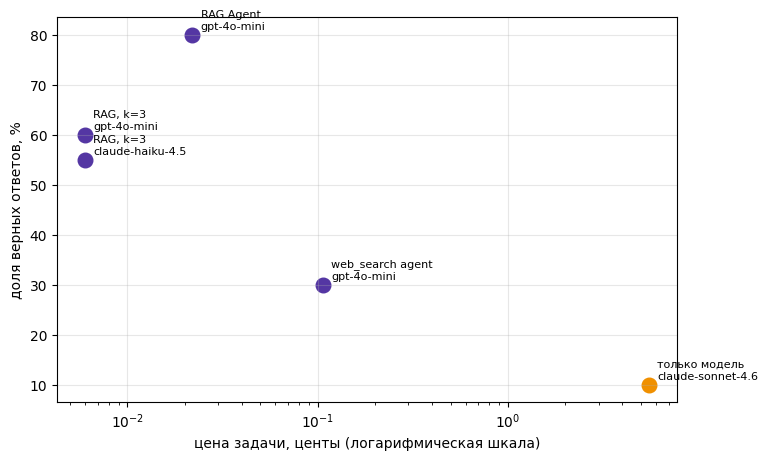

In [130]:
money_chart(table, "img/money.png");

In [127]:
trace = json.loads(next((TRACES / "RAG" / "gpt-4o-mini").glob("fresh-*.json")).read_text(encoding="utf-8"))
show_trace(Run(trace["task"]["question"], trace["answer"], sum(m["role"] == "assistant" for m in trace["messages"]), trace["messages"], trace["cost"]))

user     | What is the name of the Chinese experimental tokamak that reported the first experimental verification of a density-free plasma operating regime on 1 January 2026? 
assistant|  rag_answer{"question":"Chinese experimental tokamak that reported the first experimental verification of a density-free plasma operating regime on 1 January 2026"}
tool     | {'answer': 'The Chinese experimental tokamak that reported the first experimental verification of a density-free plasma operating regime is the Experimental Advanced Superconductin 
assistant| The Chinese experimental tokamak that reported the first experimental verification of a density-free plasma operating regime on 1 January 2026 is the Experimental Advanced Supercon 
шагов: 2, цена: 0.022 ¢, время: 0.0 c


### ШАг 3.4 RAG на вопросах, которых нет в корпусе

In [133]:
unk_task = load_jsonl('fresh_unk_2026.jsonl')
result_rag_unk = evaluate(rag_answer, unk_task, "RAG, k=3", MODELS["cheap"])
result_rag_unk

,config,model,id,correct,found,refused,cost,answer,gold
0,"RAG, k=3",gpt-4o-mini,fresh-10,False,False,True,0.000057,NOT_FOUND,unknown
1,"RAG, k=3",gpt-4o-mini,fresh-11,False,False,False,0.000099,The Migdal effect is a quantum process where a...,unknown
2,"RAG, k=3",gpt-4o-mini,fresh-12,False,False,True,0.000056,young supermassive black holes.,unknown
3,"RAG, k=3",gpt-4o-mini,fresh-13,False,False,True,0.000048,NOT_FOUND.,unknown
4,"RAG, k=3",gpt-4o-mini,fresh-14,False,False,True,0.000052,NOT_FOUND,unknown
5,"RAG, k=3",gpt-4o-mini,fresh-15,False,False,True,0.000063,NOT_FOUND.,unknown
6,"RAG, k=3",gpt-4o-mini,fresh-16,False,False,True,0.000084,A 'super-puff' planet is a low-density giant p...,unknown
7,"RAG, k=3",gpt-4o-mini,fresh-17,False,False,True,0.000051,NOT_FOUND.,unknown
8,"RAG, k=3",gpt-4o-mini,fresh-18,False,False,True,0.000042,NOT_FOUND.,unknown
9,"RAG, k=3",gpt-4o-mini,fresh-19,False,False,True,0.000045,NOT_FOUND.,unknown


In [62]:
def diagnose(results):
    wrong = results[~results["correct"] & results["config"].str.startswith("RAG")]
    return wrong.groupby("model").agg(не_нашли=("found", lambda s: int((~s).sum())), нашли_но_ответ_неверный=("found", "sum"))

diagnose(results)

,не_нашли,нашли_но_ответ_неверный
model,,
claude-haiku-4.5,1,0
claude-sonnet-4.6,1,1
gpt-4o-mini,1,2


In [63]:
results[~results["correct"] & (results["config"] == "RAG, k=5")][["model", "gold", "answer", "found"]]

,model,gold,answer,found
82,gpt-4o-mini,Miguel Díaz-Canel,NOT_FOUND.,False
85,gpt-4o-mini,two people,2,True
108,gpt-4o-mini,43,46,True
122,claude-haiku-4.5,Miguel Díaz-Canel,NOT_FOUND,False
162,claude-sonnet-4.6,Miguel Díaz-Canel,Iran,False
165,claude-sonnet-4.6,two people,2,True


In [64]:
def tokens(text):
    return re.findall(r"\w+", text.lower())

def build_keyword_index(texts):
    docs = [set(tokens(text)) for text in texts]
    df = {}
    for d in docs:
        for w in d:
            df[w] = df.get(w, 0) + 1
    return docs, {w: np.log(len(docs) / n) for w, n in df.items()}

def keyword_search(query, docs, idf, k=20):
    q = set(tokens(query))
    scores = np.array([sum(idf.get(w, 0.0) for w in q & d) for d in docs])
    return [int(i) for i in np.argsort(-scores)[:k]]

In [65]:
def rrf(rankings, k=5, K=60):
    scores = {}
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            scores[idx] = scores.get(idx, 0.0) + 1 / (K + rank + 1)

    return sorted(scores, key=scores.get, reverse=True)[:k]
        


,нарезка,поиск,recall@1,recall@5
0,по 400 символов,только вектор,0.52,0.81
1,по 400 символов,только слова,0.76,0.90
2,по 400 символов,гибрид RRF,0.73,0.90
3,по строкам,только вектор,0.88,0.98
4,по строкам,только слова,0.89,0.98
5,по строкам,гибрид RRF,0.90,1.00


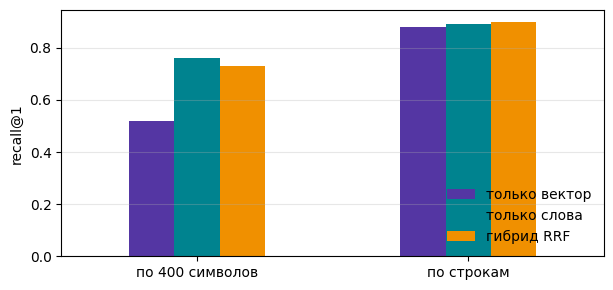

In [66]:
def recall_of(rankings, chunks, k=5):
    return float(np.mean([any(is_gold(chunks[i], t) for i in r[:k]) for r, t in zip(rankings, tasks)]))

rows = []
for cut, chunks, vectors, texts in [("по 400 символов", char_chunks, char_vecs, [c["text"] for c in char_chunks]),
                                    ("по строкам", line_chunks, line_vecs, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_vector = [[i for i, _ in search_numpy(q, vectors, 20)] for q in q_vecs]
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(by_vector, by_words)]
    rows += [{"нарезка": cut, "поиск": name, "recall@1": recall_of(r, chunks, 1), "recall@5": recall_of(r, chunks, 5)}
             for name, r in [("только вектор", by_vector), ("только слова", by_words), ("гибрид RRF", by_hybrid)]]
hybrid = pd.DataFrame(rows).round(2)
ax = hybrid.pivot(index="нарезка", columns="поиск", values="recall@1")[["только вектор", "только слова", "гибрид RRF"]].plot.bar(
    figsize=(7, 3.2), color=[COLORS["violet"], COLORS["teal"], COLORS["amber"]], rot=0)
ax.set_ylabel("recall@1"); ax.set_xlabel(""); ax.legend(frameon=False, loc="lower right"); ax.grid(alpha=0.3, axis="y")
hybrid

In [67]:
UNANSWERABLE = ["Who won the Nobel Prize in Literature announced in October 2026?", "Which team won the 2026 World Series in baseball?",
                "Who won the 2026 Formula One World Drivers' Championship?", "Which country won the Eurovision Song Contest 2027?",
                "Who won the United States Senate election in Maine held on November 3, 2026?", "Which film won the Palme d'Or at the 2027 Cannes Film Festival?",
                "What was the magnitude of the earthquake that struck Lisbon in December 2026?", "Who won the Nobel Peace Prize announced in October 2026?",
                "Which company first reached a ten trillion dollar valuation in November 2026?", "Who won the 2026 World Chess Championship match in December 2026?"]
refusals = [rag_answer(q, MODELS["cheap"]) for q in UNANSWERABLE]
sum("NOT_FOUND" in r["answer"] for r in refusals), [final_answer(r["answer"])[:40] for r in refusals if "NOT_FOUND" not in r["answer"]]

(10, [])

(0.753, 0.567)

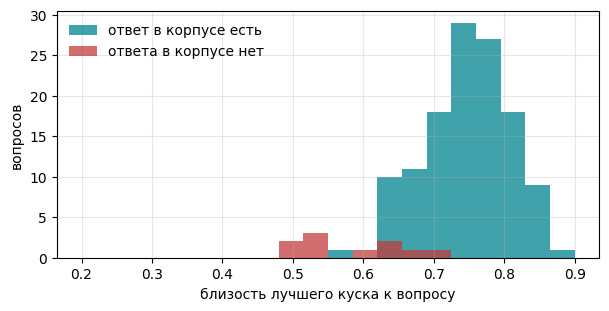

In [68]:
top_answerable = [search_numpy(q, line_vecs, 1)[0][1] for q in q_vecs]
top_unanswerable = [r["hits"][0]["score"] for r in refusals]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(top_answerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["teal"], label="ответ в корпусе есть")
ax.hist(top_unanswerable, bins=20, range=(0.2, 0.9), alpha=0.75, color=COLORS["red"], label="ответа в корпусе нет")
ax.set_xlabel("близость лучшего куска к вопросу"); ax.set_ylabel("вопросов"); ax.legend(frameon=False); ax.grid(alpha=0.3)
round(float(np.median(top_answerable)), 3), round(float(np.median(top_unanswerable)), 3)